# Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torchvision
import optuna
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import seaborn as sns

from torch import optim
from torch import nn
from torch.utils.data import DataLoader
import torch.nn.functional as F

from tqdm import tqdm
import torchvision.datasets as datasets
import torchvision.transforms as transforms 
device = "cuda" if torch.cuda.is_available() else "cpu"


# Loading the MNIST dataset

In [84]:
batch_size = 60
train_size = 50000
validation_size = 10000

train_validation_dataset = datasets.MNIST(root="dataset/", download=True, train=True, transform=transforms.ToTensor())

train_dataset, validation_dataset = torch.utils.data.random_split(train_validation_dataset, [train_size, validation_size])

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

validation_loader = DataLoader(dataset=validation_dataset, batch_size=batch_size, shuffle=False)

test_dataset = datasets.MNIST(root="dataset/", download=True, train=False, transform=transforms.ToTensor())

test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

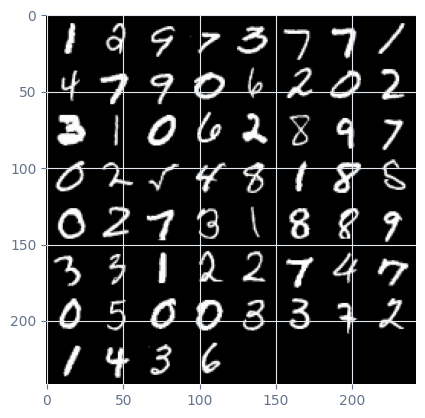

In [85]:
def imshow(img):
   npimg = img.numpy()
   plt.imshow(np.transpose(npimg, (1, 2, 0)))
   plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)
labels
imshow(torchvision.utils.make_grid(images))


## Model

In [86]:
# Model
class CNN(nn.Module):
   def __init__(self, in_channels, num_classes):

       """
       Parameters:
           * in_channels: Number of channels in the input image (for grayscale images, 1)
           * num_classes: Number of classes to predict. MNIST, 10.
       """
       super(CNN, self).__init__()

       self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=8, kernel_size=3, padding=1)
       self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
       self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
       self.fc1 = nn.Linear(16 * 7 * 7, num_classes)
       self.dropout = nn.Dropout(0.5)

   def forward(self, x):
       """
       Define the forward pass of the neural network.

       Parameters:
           x: Input tensor.

       Returns:
           torch.Tensor
               The output tensor after passing through the network.
       """
       x = F.relu(self.conv1(x))  # Apply first convolution and ReLU activation
       x = self.pool(x)           # Apply max pooling
       x = F.relu(self.conv2(x))  # Apply second convolution and ReLU activation
       x = self.pool(x)           # Apply max pooling
       x = x.reshape(x.shape[0], -1)  # Flatten the tensor
       x = self.dropout(x)        # Apply dropout
       x = self.fc1(x)            # Apply fully connected layer
       return x

## Tunning

In [87]:
def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD"])

    model_tune = CNN(in_channels=1, num_classes=10).to(device)
    # Define a local loss function so objective doesn't depend on external cells
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer_tune = optim.Adam(model_tune.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer_tune = optim.SGD(model_tune.parameters(), lr=lr, weight_decay=weight_decay, momentum=0.9)

    tune_epochs = 5
    
    for epoch in range(tune_epochs):
        model_tune.train()
        
        for data, targets in train_loader:
            data, targets = data.to(device), targets.to(device)
            scores = model_tune(data)
            loss = criterion(scores, targets)
            
            optimizer_tune.zero_grad()
            loss.backward()
            optimizer_tune.step()
            
    model_tune.eval()
    accepted = 0
    total = 0
    
    with torch.no_grad():
        for data, targets in validation_loader:
            data, targets = data.to(device), targets.to(device)
            scores = model_tune(data)
            _, predictions = scores.max(1)
            total += targets.size(0)
            accepted += (predictions == targets).sum().item()
            
    accuracy = 100 * accepted / total
    
    return accuracy

In [88]:
optuna.logging.set_verbosity(optuna.logging.INFO)

print("Starting Tuning\n")

study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=10)

print("TUNING COMPLETE")
print(f"Best Validation Accuracy achieved: {study.best_trial.value:.2f}%")
print("Best Hyperparameters:")
for key, value in study.best_trial.params.items():
    print(f"    {key}: {value}")

[I 2026-05-12 13:52:19,450] A new study created in memory with name: no-name-68d7cc3c-33bd-458f-bdf3-ccfadfb82496


Starting Tuning



[I 2026-05-12 13:52:37,331] Trial 0 finished with value: 87.88 and parameters: {'lr': 0.00018446061778841394, 'weight_decay': 7.045741055329376e-05, 'optimizer': 'SGD'}. Best is trial 0 with value: 87.88.
[I 2026-05-12 13:52:54,409] Trial 1 finished with value: 95.45 and parameters: {'lr': 0.03318554868947978, 'weight_decay': 5.676054634036153e-06, 'optimizer': 'Adam'}. Best is trial 1 with value: 95.45.
[I 2026-05-12 13:53:11,266] Trial 2 finished with value: 91.97 and parameters: {'lr': 0.0002776281668390336, 'weight_decay': 4.183767937613554e-06, 'optimizer': 'SGD'}. Best is trial 1 with value: 95.45.
[I 2026-05-12 13:53:27,856] Trial 3 finished with value: 97.26 and parameters: {'lr': 0.002925475896172306, 'weight_decay': 1.5481231585987951e-06, 'optimizer': 'SGD'}. Best is trial 3 with value: 97.26.
[I 2026-05-12 13:53:45,186] Trial 4 finished with value: 97.48 and parameters: {'lr': 0.011990663116640416, 'weight_decay': 2.495197456062027e-06, 'optimizer': 'Adam'}. Best is trial 4

TUNING COMPLETE
Best Validation Accuracy achieved: 98.24%
Best Hyperparameters:
    lr: 0.011041545217826623
    weight_decay: 3.011847379581113e-06
    optimizer: SGD


## Settings

In [89]:
model = CNN(in_channels=1, num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()

learning_rate = 0.006330666857859053
weight_decay = 0.000241618414186194

optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

## Train

In [131]:
num_epochs=10

hist_train_loss = []
hist_val_loss = []
hist_val_acc = []

for epoch in range(num_epochs):
   model.train()
   all_targets_cnn = []
   all_predictions_cnn = []
   print(f"Epoch [{epoch + 1}/{num_epochs}]")

   train_loss_epoch = 0

   for batch_index, (data, targets) in enumerate(tqdm(train_loader)):
       data = data.to(device)
       targets = targets.to(device)
       scores = model(data)
       loss = criterion(scores, targets)
       optimizer.zero_grad()
       loss.backward()
       optimizer.step()
       train_loss_epoch += loss.item()

   model.eval()
        
   accepted = 0
   total = 0
   val_loss = 0
   with torch.no_grad():
      for data, targets in validation_loader:
         data = data.to(device)
         targets = targets.to(device)
         scores = model(data)
         error_batch = criterion(scores, targets)
         val_loss += error_batch.item()
         _, predictions = scores.max(1)
         total += targets.size(0)
         accepted += (predictions == targets).sum().item()
         all_targets_cnn.extend(targets.cpu().numpy())
         all_predictions_cnn.extend(predictions.cpu().numpy())

   accuracy = 100 * accepted / total
   
   mean_val_loss = val_loss / len(validation_loader) 
   mean_train_loss = train_loss_epoch / len(train_loader)
   
   print(f"Train     -> Loss: {mean_train_loss:.4f}")
   print(f"Validation -> Loss: {mean_val_loss:.4f} | Accuracy: {accuracy:.2f}%\n")

   hist_train_loss.append(mean_train_loss)
   hist_val_loss.append(mean_val_loss)
   hist_val_acc.append(accuracy)


Epoch [1/10]


100%|██████████| 834/834 [00:04<00:00, 202.53it/s]


Train     -> Loss: 0.1261
Validation -> Loss: 0.0551 | Accuracy: 98.31%

Epoch [2/10]


100%|██████████| 834/834 [00:03<00:00, 210.28it/s]


Train     -> Loss: 0.1235
Validation -> Loss: 0.0609 | Accuracy: 98.15%

Epoch [3/10]


...

Train     -> Loss: 0.1204
Validation -> Loss: 0.0561 | Accuracy: 98.24%

Epoch [9/10]


100%|██████████| 834/834 [00:04<00:00, 203.37it/s]


Train     -> Loss: 0.1208
Validation -> Loss: 0.0536 | Accuracy: 98.29%

Epoch [10/10]


100%|██████████| 834/834 [00:03<00:00, 219.96it/s]


Train     -> Loss: 0.1156
Validation -> Loss: 0.0556 | Accuracy: 98.26%



## Resnet 50 

In [138]:
resnet_model = resnet50(weights=ResNet50_Weights.DEFAULT)

resnet_model.conv1 = nn.Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)

num_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_features, 10)

resnet_model = resnet_model.to(device)

criterion = nn.CrossEntropyLoss()

learning_rate = 0.006330666857859053
weight_decay = 0.000241618414186194
optimizer_resnet = optim.Adam(resnet_model.parameters(), lr=learning_rate, weight_decay=weight_decay)

In [139]:
hist_resnet_train_loss = []
hist_resnet_val_loss = []
hist_resnet_val_acc = []

num_epochs = 10

for epoch in range(num_epochs):
    resnet_model.train() 
    train_loss_epoch = 0
    
    all_targets_resnet = []
    all_predictions_resnet = []
    print(f"Epoch [{epoch + 1}/{num_epochs}]")
    
    for batch_index, (data, targets) in enumerate(tqdm(train_loader)):
        data, targets = data.to(device), targets.to(device)
        
        scores = resnet_model(data)
        loss = criterion(scores, targets)
        
        optimizer_resnet.zero_grad()
        loss.backward()
        optimizer_resnet.step()
        
        train_loss_epoch += loss.item()
    resnet_model.eval()
    accepted = 0
    total = 0
    val_loss = 0
    
    with torch.no_grad():
        for data, targets in validation_loader:
            data, targets = data.to(device), targets.to(device)
            
            scores = resnet_model(data)
            error_batch = criterion(scores, targets)
            
            val_loss += error_batch.item()
            _, predictions = scores.max(1)
            total += targets.size(0)
            accepted += (predictions == targets).sum().item()
            all_targets_resnet.extend(targets.cpu().numpy())
            all_predictions_resnet.extend(predictions.cpu().numpy())

    accuracy = 100 * accepted / total
    mean_val_loss = val_loss / len(validation_loader)
    mean_train_loss = train_loss_epoch / len(train_loader)
    
    print(f"ResNet -> Treino Loss: {mean_train_loss:.4f} | Val Loss: {mean_val_loss:.4f} | Val Acc: {accuracy:.2f}%\n")
    
    hist_resnet_train_loss.append(mean_train_loss)
    hist_resnet_val_loss.append(mean_val_loss)
    hist_resnet_val_acc.append(accuracy)

Epoch [1/10]


100%|██████████| 834/834 [02:13<00:00,  6.24it/s]


ResNet -> Treino Loss: 0.9319 | Val Loss: 0.2019 | Val Acc: 94.08%

Epoch [2/10]


100%|██████████| 834/834 [02:06<00:00,  6.59it/s]


ResNet -> Treino Loss: 0.2864 | Val Loss: 0.1364 | Val Acc: 96.04%

Epoch [3/10]


...

ResNet -> Treino Loss: 0.0867 | Val Loss: 0.1000 | Val Acc: 97.00%

Epoch [9/10]


100%|██████████| 834/834 [02:03<00:00,  6.74it/s]


ResNet -> Treino Loss: 0.0815 | Val Loss: 0.0876 | Val Acc: 97.32%

Epoch [10/10]


100%|██████████| 834/834 [02:03<00:00,  6.75it/s]


ResNet -> Treino Loss: 0.0797 | Val Loss: 0.0654 | Val Acc: 98.12%



## Results

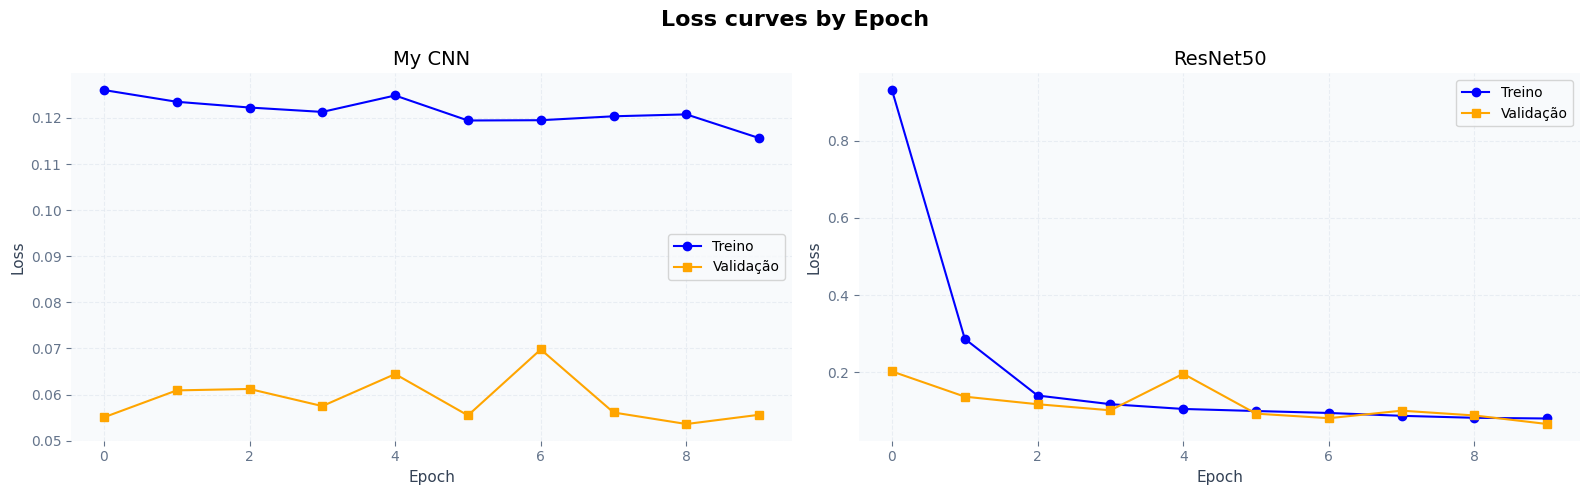

In [140]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Loss curves by Epoch', fontsize=16, fontweight='bold')
    
axs[0].plot(hist_train_loss, label='Treino', marker='o', color='blue')
axs[0].plot(hist_val_loss, label='Validação', marker='s', color='orange')
axs[0].set_title('My CNN', fontsize=14)
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.7)

axs[1].plot(hist_resnet_train_loss, label='Treino', marker='o', color='blue')
axs[1].plot(hist_resnet_val_loss, label='Validação', marker='s', color='orange')
axs[1].set_title('ResNet50', fontsize=14)
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

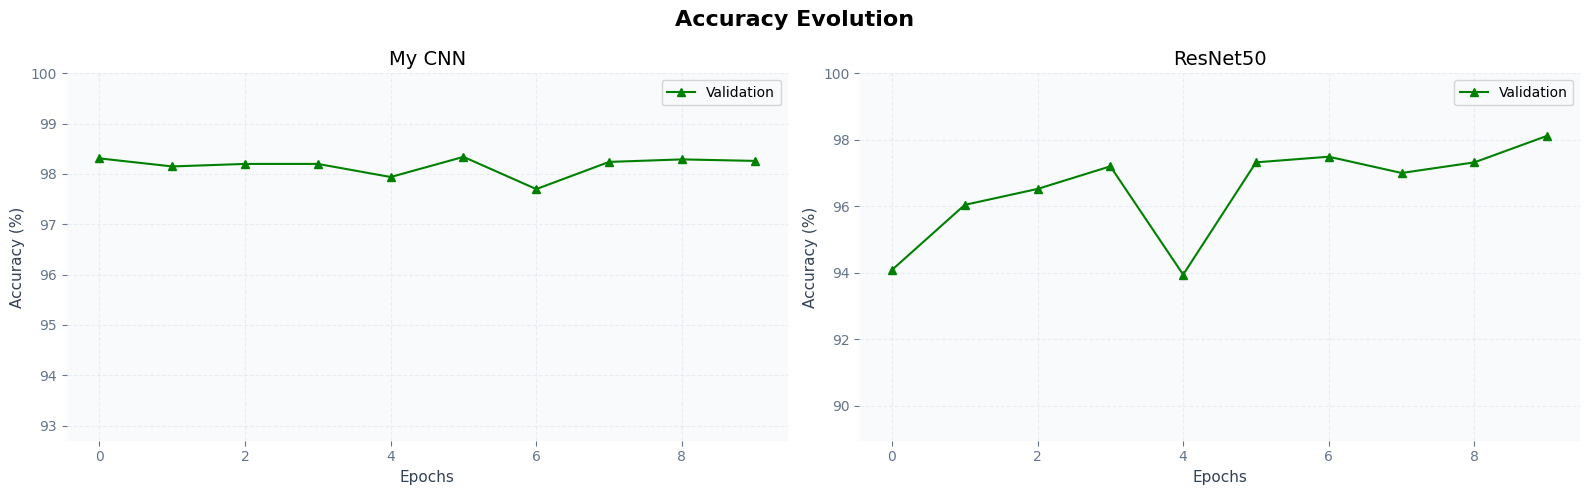

In [141]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Accuracy Evolution', fontsize=16, fontweight='bold')


axs[0].plot(hist_val_acc, label='Validation', marker='^', color='green')
axs[0].set_title('My CNN', fontsize=14)
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Accuracy (%)')
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.7)
axs[0].set_ylim([min(hist_val_acc)-5, 100])

axs[1].plot(hist_resnet_val_acc, label='Validation', marker='^', color='green')
axs[1].set_title('ResNet50', fontsize=14)
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy (%)')
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.7)
axs[1].set_ylim([min(hist_resnet_val_acc)-5, 100])

plt.tight_layout()
plt.show()

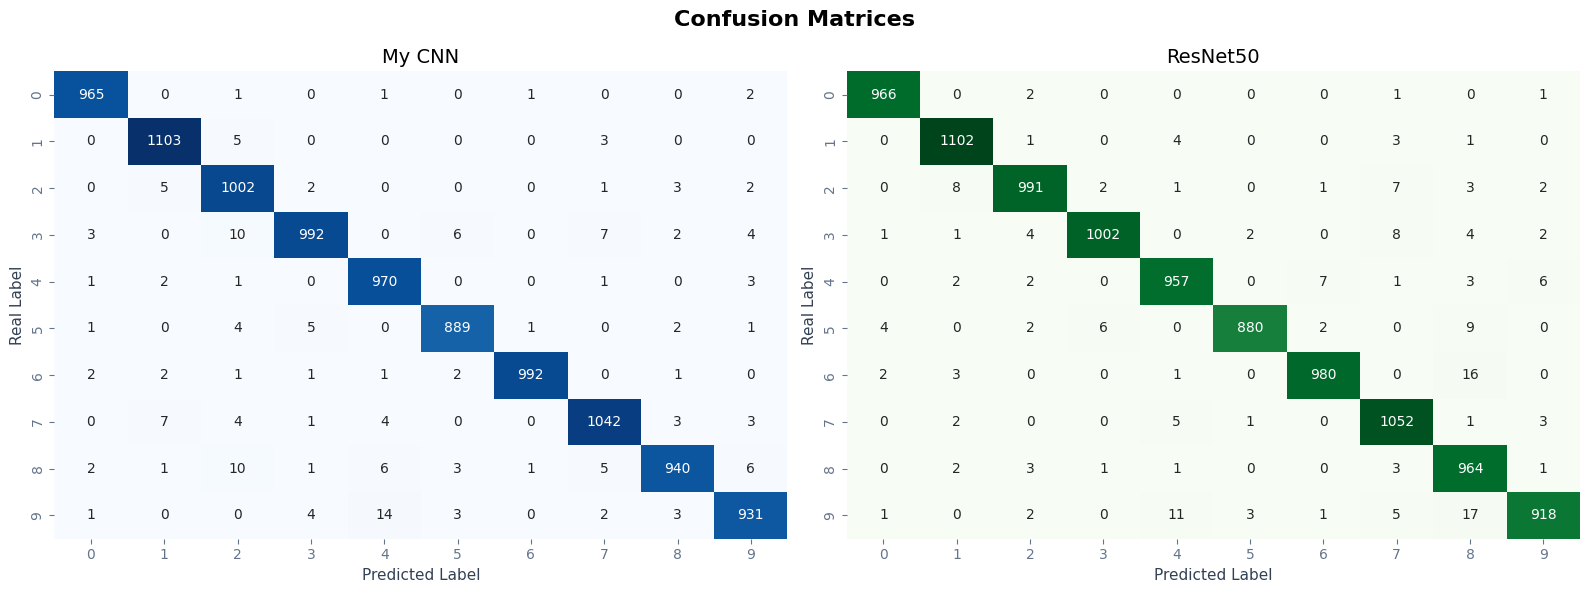

In [142]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')

cm_cnn = confusion_matrix(all_targets_cnn, all_predictions_cnn)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', ax=axs[0], cbar=False)
axs[0].set_title('My CNN', fontsize=14)
axs[0].set_xlabel('Predicted Label')
axs[0].set_ylabel('Real Label')
axs[0].grid(False)

cm_resnet = confusion_matrix(all_targets_resnet, all_predictions_resnet)
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Greens', ax=axs[1], cbar=False)
axs[1].set_title('ResNet50', fontsize=14)
axs[1].set_xlabel('Predicted Label')
axs[1].set_ylabel('Real Label')
axs[1].grid(False)

plt.tight_layout()
plt.show()

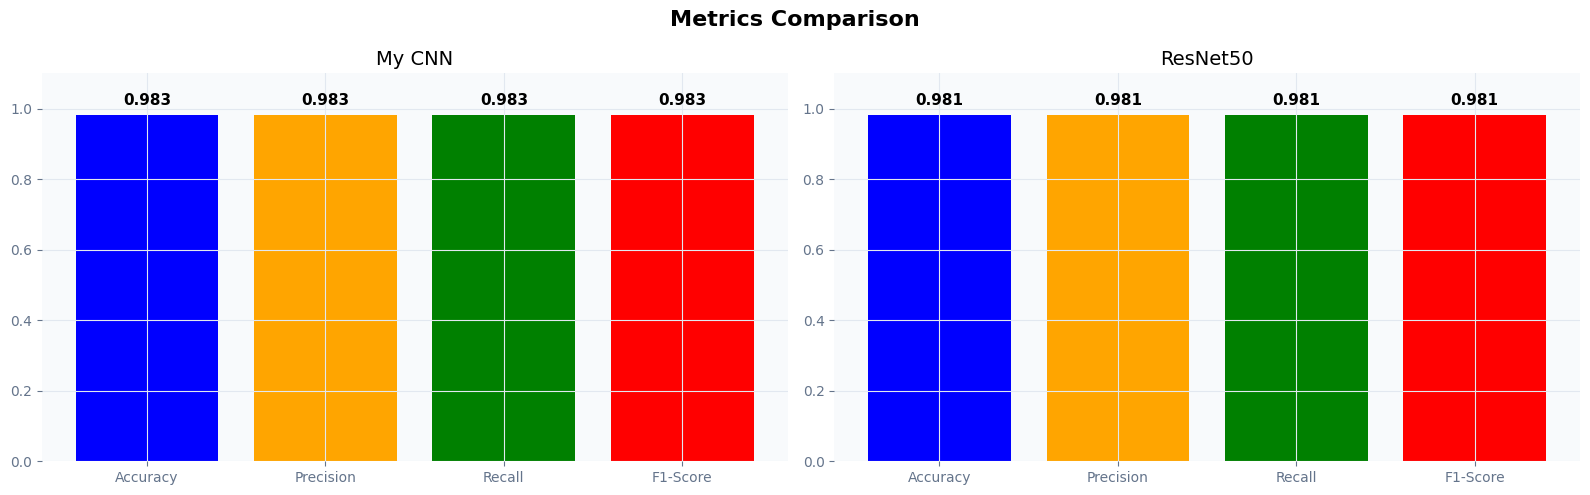

In [143]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Metrics Comparison', fontsize=16, fontweight='bold')

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['blue', 'orange', 'green', 'red']

acc_cnn = accuracy_score(all_targets_cnn, all_predictions_cnn)
prec_cnn, rec_cnn, f1_cnn, _ = precision_recall_fscore_support(all_targets_cnn, all_predictions_cnn, average='macro', zero_division=0)
metrics_cnn = [acc_cnn, prec_cnn, rec_cnn, f1_cnn]

bars1 = axs[0].bar(metrics_names, metrics_cnn, color=colors)
axs[0].set_title('My CNN', fontsize=14)
axs[0].set_ylim(0, 1.1)
for bar in bars1:
    yval = bar.get_height()
    axs[0].text(bar.get_x() + bar.get_width()/2, yval + 0.02, 
                    f'{yval:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

acc_resnet = accuracy_score(all_targets_resnet, all_predictions_resnet)
prec_resnet, rec_resnet, f1_resnet, _ = precision_recall_fscore_support(all_targets_resnet, all_predictions_resnet, average='macro', zero_division=0)
metrics_resnet = [acc_resnet, prec_resnet, rec_resnet, f1_resnet]

bars2 = axs[1].bar(metrics_names, metrics_resnet, color=colors)
axs[1].set_title('ResNet50', fontsize=14)
axs[1].set_ylim(0, 1.1)
for bar in bars2:
    yval = bar.get_height()
    axs[1].text(bar.get_x() + bar.get_width()/2, yval + 0.02, 
                    f'{yval:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# CIFAR10

In [103]:
batch_size = 60
train_size = 40000
validation_size = 10000

train_validation_dataset_CIFAR10 = datasets.CIFAR10(root="dataset/", download=True, train=True, transform=transforms.ToTensor())

train_dataset_CIFAR10, validation_dataset_CIFAR10 = torch.utils.data.random_split(train_validation_dataset_CIFAR10, [train_size, validation_size])

train_loader_CIFAR10 = DataLoader(dataset=train_dataset_CIFAR10, batch_size=batch_size, shuffle=True)

validation_loader_CIFAR10 = DataLoader(dataset=validation_dataset_CIFAR10, batch_size=batch_size, shuffle=False)

test_dataset_CIFAR10 = datasets.CIFAR10(root="dataset/", download=True, train=False, transform=transforms.ToTensor())

test_loader_CIFAR10 = DataLoader(dataset=test_dataset_CIFAR10, batch_size=batch_size, shuffle=False)

/home/alber/Documents/P8/deep/CNN_implementation/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


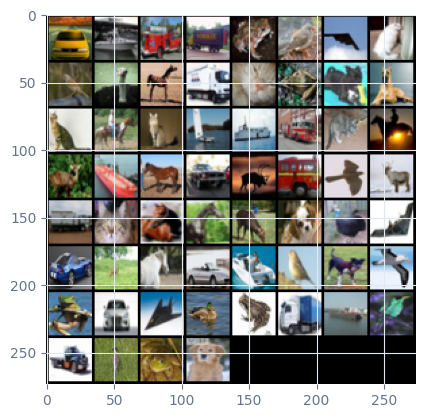

In [104]:
def imshow(img):
   npimg = img.numpy()
   plt.imshow(np.transpose(npimg, (1, 2, 0)))
   plt.show()

dataiter = iter(train_loader_CIFAR10)
images, labels = next(dataiter)
labels
imshow(torchvision.utils.make_grid(images))


## Model

In [116]:
class CNN_CIFAR10(nn.Module):
    def __init__(self, in_channels=3, num_classes=10):
        super(CNN_CIFAR10, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.5)
        
        self.fc1 = nn.Linear(128 * 4 * 4, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        return self.fc1(x)

## Tunning

In [106]:
def objective_CIFAR10(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD"])

    model_tune = CNN_CIFAR10(in_channels=3, num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer_tune = optim.Adam(model_tune.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer_tune = optim.SGD(model_tune.parameters(), lr=lr, weight_decay=weight_decay, momentum=0.9)

    tune_epochs = 5
    
    for epoch in range(tune_epochs):
        model_tune.train()
        
        for data, targets in train_loader_CIFAR10:
            data, targets = data.to(device), targets.to(device)
            scores = model_tune(data)
            loss = criterion(scores, targets)
            
            optimizer_tune.zero_grad()
            loss.backward()
            optimizer_tune.step()
            
    model_tune.eval()
    accepted = 0
    total = 0
    
    with torch.no_grad():
        for data, targets in validation_loader_CIFAR10:
            data, targets = data.to(device), targets.to(device)
            scores = model_tune(data)
            _, predictions = scores.max(1)
            total += targets.size(0)
            accepted += (predictions == targets).sum().item()
            
    accuracy = 100 * accepted / total
    
    return accuracy

In [107]:
optuna.logging.set_verbosity(optuna.logging.INFO)

print("Starting Tuning\n")

study = optuna.create_study(direction="maximize")

study.optimize(objective_CIFAR10, n_trials=10)

print("TUNING COMPLETE")
print(f"Best Validation Accuracy achieved: {study.best_trial.value:.2f}%")
print("Best Hyperparameters:")
for key, value in study.best_trial.params.items():
    print(f"    {key}: {value}")

[I 2026-05-12 14:21:21,750] A new study created in memory with name: no-name-01ad8174-cdd4-480a-9545-c44d9a38330a


Starting Tuning



[I 2026-05-12 14:21:41,115] Trial 0 finished with value: 42.92 and parameters: {'lr': 0.00015275316285734604, 'weight_decay': 0.0005676766053446958, 'optimizer': 'Adam'}. Best is trial 0 with value: 42.92.
[I 2026-05-12 14:22:00,429] Trial 1 finished with value: 56.26 and parameters: {'lr': 0.007843239020093613, 'weight_decay': 1.502881882866927e-05, 'optimizer': 'SGD'}. Best is trial 1 with value: 56.26.
[I 2026-05-12 14:22:18,785] Trial 2 finished with value: 57.95 and parameters: {'lr': 0.013453688560880604, 'weight_decay': 2.794898727676797e-06, 'optimizer': 'SGD'}. Best is trial 2 with value: 57.95.
[I 2026-05-12 14:22:36,928] Trial 3 finished with value: 56.34 and parameters: {'lr': 0.022343400500740053, 'weight_decay': 0.0003095903915163411, 'optimizer': 'SGD'}. Best is trial 2 with value: 57.95.
[I 2026-05-12 14:22:54,342] Trial 4 finished with value: 29.77 and parameters: {'lr': 0.00030793156479802086, 'weight_decay': 0.008301751927306355, 'optimizer': 'SGD'}. Best is trial 2 

TUNING COMPLETE
Best Validation Accuracy achieved: 57.95%
Best Hyperparameters:
    lr: 0.013453688560880604
    weight_decay: 2.794898727676797e-06
    optimizer: SGD


## Settings

In [117]:
model_cnn = CNN_CIFAR10(in_channels=3, num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
learning_rate = 0.002238048452572137
weight_decay = 0.0017964643709170035
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=learning_rate, weight_decay=weight_decay)

## Train

In [120]:
num_epochs = 10

hist_cnn_train_loss_CIFAR10 = []
hist_cnn_val_loss_CIFAR10 = []
hist_cnn_val_acc_CIFAR10 = []

for epoch in range(num_epochs):
    model_cnn.train()
    train_loss_epoch = 0
    
    all_targets_cnn_CIFAR10 = []
    all_predictions_cnn_CIFAR10 = []
    print(f"Epoch [{epoch + 1}/{num_epochs}]")
    
    for data, targets in tqdm(train_loader_CIFAR10, desc="Train CNN"):
        data, targets = data.to(device), targets.to(device)
        scores = model_cnn(data)
        loss = criterion(scores, targets)    
        optimizer_cnn.zero_grad()
        loss.backward()
        optimizer_cnn.step()
        train_loss_epoch += loss.item()
        
    model_cnn.eval()
    accepted = 0
    total = 0
    val_loss = 0
    
    with torch.no_grad():
        for data, targets in validation_loader_CIFAR10:
            data, targets = data.to(device), targets.to(device)
            scores = model_cnn(data)
            
            error_batch = criterion(scores, targets)
            val_loss += error_batch.item()
            
            _, predictions = scores.max(1)
            total += targets.size(0)
            accepted += (predictions == targets).sum().item()
            all_targets_cnn_CIFAR10.extend(targets.cpu().numpy())
            all_predictions_cnn_CIFAR10.extend(predictions.cpu().numpy())
    
    accuracy = 100 * accepted / total
    mean_val_loss = val_loss / len(validation_loader_CIFAR10)
    mean_train_loss = train_loss_epoch / len(train_loader_CIFAR10)
    
    print(f"Train Loss: {mean_train_loss:.4f} | Val Loss: {mean_val_loss:.4f} | Val Acc: {accuracy:.2f}%\n")
    
    hist_cnn_train_loss_CIFAR10.append(mean_train_loss)
    hist_cnn_val_loss_CIFAR10.append(mean_val_loss)
    hist_cnn_val_acc_CIFAR10.append(accuracy)

Epoch [1/10]


Train CNN: 100%|██████████| 667/667 [00:13<00:00, 48.72it/s]


Train Loss: 0.7664 | Val Loss: 0.9066 | Val Acc: 69.67%

Epoch [2/10]


Train CNN: 100%|██████████| 667/667 [00:13<00:00, 50.61it/s]


Train Loss: 0.7613 | Val Loss: 1.0680 | Val Acc: 66.11%

Epoch [3/10]


...

Train Loss: 0.7285 | Val Loss: 0.8983 | Val Acc: 69.55%

Epoch [9/10]


Train CNN: 100%|██████████| 667/667 [00:12<00:00, 53.94it/s]


Train Loss: 0.7234 | Val Loss: 1.3192 | Val Acc: 58.66%

Epoch [10/10]


Train CNN: 100%|██████████| 667/667 [00:12<00:00, 53.44it/s]


Train Loss: 0.7238 | Val Loss: 0.9604 | Val Acc: 66.81%



## Resnet

In [121]:
resnet_model_CIFAR10 = resnet50(weights=ResNet50_Weights.DEFAULT)

resnet_model_CIFAR10.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
resnet_model_CIFAR10.maxpool = nn.Identity()

num_features = resnet_model_CIFAR10.fc.in_features
resnet_model_CIFAR10.fc = nn.Linear(num_features, 10)

resnet_model_CIFAR10 = resnet_model_CIFAR10.to(device)

optimizer_resnet_CIFAR10 = optim.Adam(
    resnet_model_CIFAR10.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [122]:
hist_resnet_train_loss_CIFAR10 = []
hist_resnet_val_loss_CIFAR10 = []
hist_resnet_val_acc_CIFAR10 = []

for epoch in range(num_epochs):
    resnet_model_CIFAR10.train()
    train_loss_epoch_CIFAR10 = 0
    
    all_targets_resnet_CIFAR10 = []
    all_predictions_resnet_CIFAR10 = []
    
    print(f"Epoch [{epoch + 1}/{num_epochs}]")
    
    for data, targets in tqdm(train_loader_CIFAR10, desc="Train ResNet50"):
        data, targets = data.to(device), targets.to(device)
        
        scores = resnet_model_CIFAR10(data)
        loss = criterion(scores, targets)
        
        optimizer_resnet_CIFAR10.zero_grad()
        loss.backward()
        optimizer_resnet_CIFAR10.step()
        
        train_loss_epoch_CIFAR10 += loss.item()
        
    resnet_model_CIFAR10.eval()
    accepted_CIFAR10 = 0
    total_CIFAR10 = 0
    val_loss_CIFAR10 = 0
    
    with torch.no_grad():
        for data, targets in validation_loader_CIFAR10:
            data, targets = data.to(device), targets.to(device)
            scores = resnet_model_CIFAR10(data)
            
            error_batch = criterion(scores, targets)
            val_loss_CIFAR10 += error_batch.item()
            
            _, predictions = scores.max(1)
            total_CIFAR10 += targets.size(0)
            accepted_CIFAR10 += (predictions == targets).sum().item()
            all_targets_resnet_CIFAR10.extend(targets.cpu().numpy())
            all_predictions_resnet_CIFAR10.extend(predictions.cpu().numpy())

    accuracy_CIFAR10 = 100 * accepted_CIFAR10 / total_CIFAR10
    mean_val_loss_CIFAR10 = val_loss_CIFAR10 / len(validation_loader_CIFAR10)
    mean_train_loss = train_loss_epoch_CIFAR10 / len(train_loader_CIFAR10)
    
    print(f"Train Loss: {mean_train_loss:.4f} | Val Loss: {mean_val_loss_CIFAR10:.4f} | Val Acc: {accuracy_CIFAR10:.2f}%\n")
    
    hist_resnet_train_loss_CIFAR10.append(mean_train_loss)
    hist_resnet_val_loss_CIFAR10.append(mean_val_loss_CIFAR10)
    hist_resnet_val_acc_CIFAR10.append(accuracy_CIFAR10 )

Epoch [1/10]


Train ResNet50: 100%|██████████| 667/667 [15:44<00:00,  1.42s/it]


Train Loss: 0.9137 | Val Loss: 0.8661 | Val Acc: 72.00%

Epoch [2/10]


Train ResNet50: 100%|██████████| 667/667 [16:25<00:00,  1.48s/it]


Train Loss: 0.5005 | Val Loss: 0.5926 | Val Acc: 80.19%

Epoch [3/10]


...

Train Loss: 0.2111 | Val Loss: 0.5625 | Val Acc: 83.18%

Epoch [9/10]


Train ResNet50: 100%|██████████| 667/667 [15:24<00:00,  1.39s/it]


Train Loss: 0.1921 | Val Loss: 0.4990 | Val Acc: 84.26%

Epoch [10/10]


Train ResNet50: 100%|██████████| 667/667 [15:39<00:00,  1.41s/it]


Train Loss: 0.1715 | Val Loss: 0.5010 | Val Acc: 84.46%



## Results

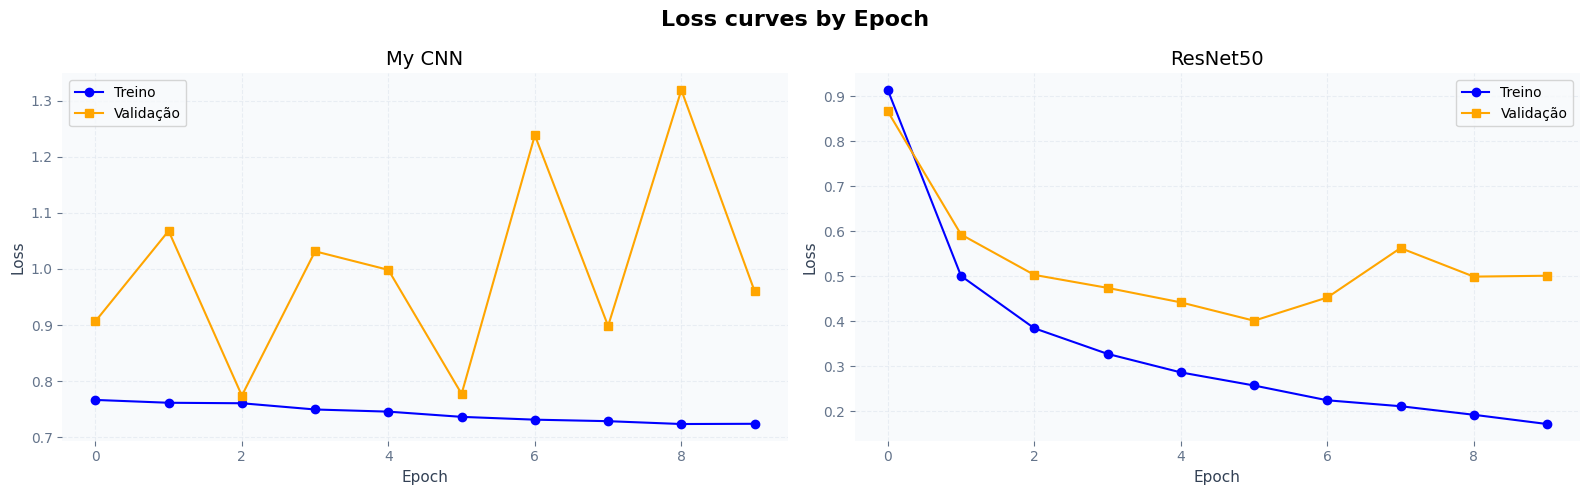

In [127]:
fig1, axs = plt.subplots(1, 2, figsize=(16, 5))
fig1.suptitle('Loss curves by Epoch', fontsize=16, fontweight='bold')
    
axs[0].plot(hist_cnn_train_loss_CIFAR10, label='Treino', marker='o', color='blue')
axs[0].plot(hist_cnn_val_loss_CIFAR10, label='Validação', marker='s', color='orange')
axs[0].set_title('My CNN', fontsize=14)
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.7)

axs[1].plot(hist_resnet_train_loss_CIFAR10, label='Treino', marker='o', color='blue')
axs[1].plot(hist_resnet_val_loss_CIFAR10, label='Validação', marker='s', color='orange')
axs[1].set_title('ResNet50', fontsize=14)
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

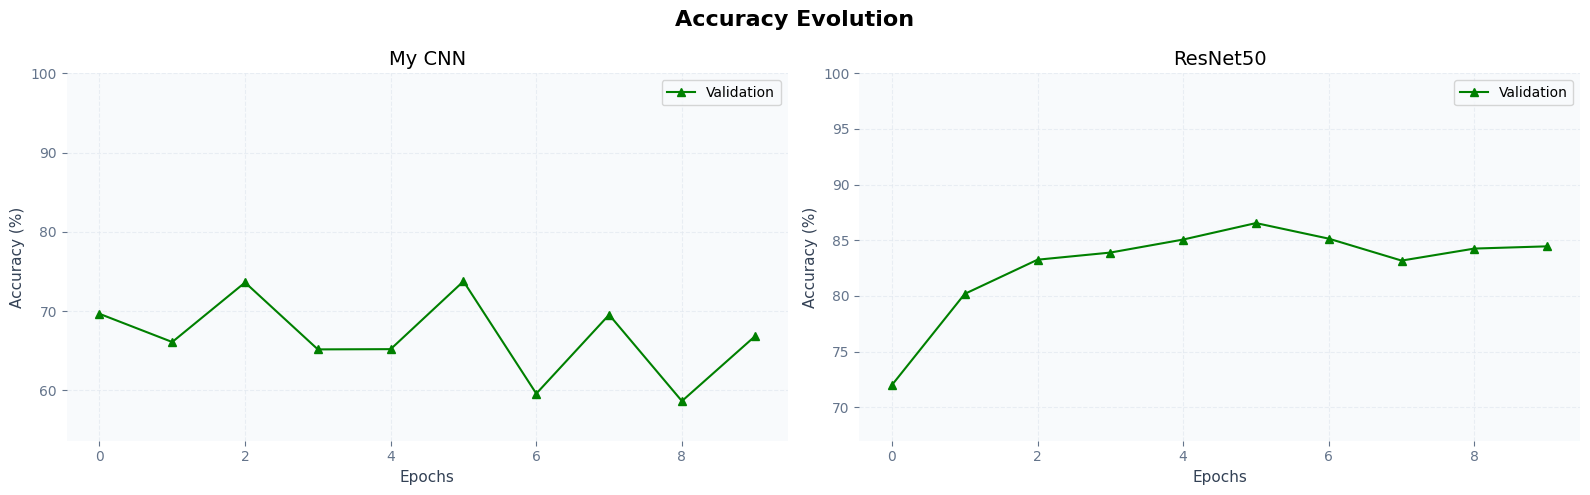

In [128]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Accuracy Evolution', fontsize=16, fontweight='bold')


axs[0].plot(hist_cnn_val_acc_CIFAR10, label='Validation', marker='^', color='green')
axs[0].set_title('My CNN', fontsize=14)
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Accuracy (%)')
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.7)
axs[0].set_ylim([min(hist_cnn_val_acc_CIFAR10)-5, 100])

axs[1].plot(hist_resnet_val_acc_CIFAR10, label='Validation', marker='^', color='green')
axs[1].set_title('ResNet50', fontsize=14)
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy (%)')
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.7)
axs[1].set_ylim([min(hist_resnet_val_acc_CIFAR10)-5, 100])

plt.tight_layout()
plt.show()

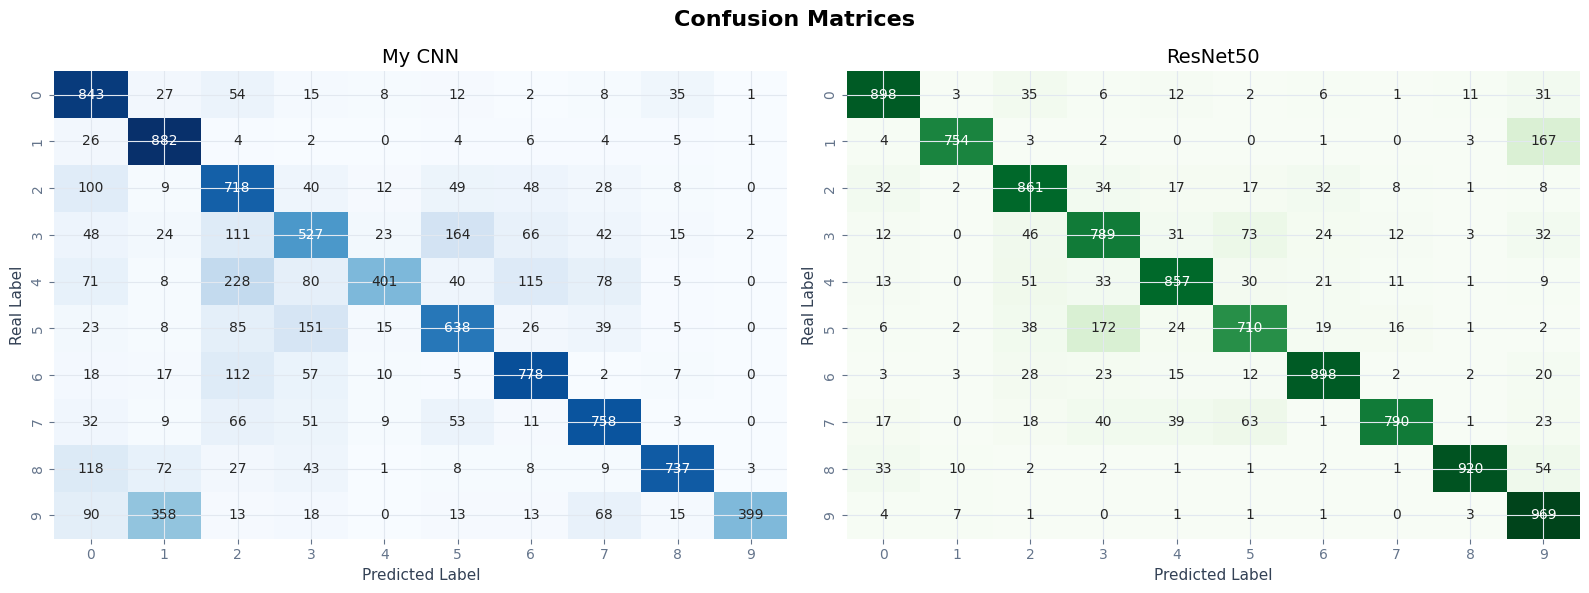

In [129]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')

cm_cnn = confusion_matrix(all_targets_cnn_CIFAR10, all_predictions_cnn_CIFAR10)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', ax=axs[0], cbar=False)
axs[0].set_title('My CNN', fontsize=14)
axs[0].set_xlabel('Predicted Label')
axs[0].set_ylabel('Real Label')


cm_resnet = confusion_matrix(all_targets_resnet_CIFAR10, all_predictions_resnet_CIFAR10)
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Greens', ax=axs[1], cbar=False)
axs[1].set_title('ResNet50', fontsize=14)
axs[1].set_xlabel('Predicted Label')
axs[1].set_ylabel('Real Label')

plt.tight_layout()
plt.show()

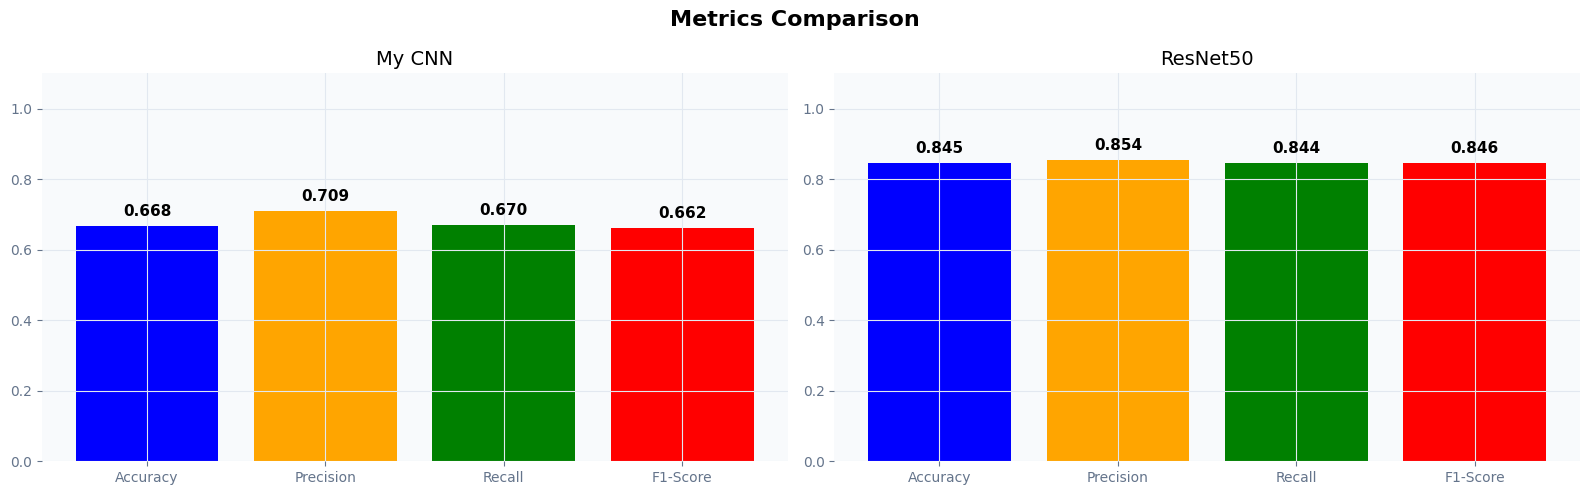

In [130]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Metrics Comparison', fontsize=16, fontweight='bold')

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['blue', 'orange', 'green', 'red']

acc_cnn = accuracy_score(all_targets_cnn_CIFAR10, all_predictions_cnn_CIFAR10)
prec_cnn, rec_cnn, f1_cnn, _ = precision_recall_fscore_support(all_targets_cnn_CIFAR10, all_predictions_cnn_CIFAR10, average='macro', zero_division=0)
metrics_cnn = [acc_cnn, prec_cnn, rec_cnn, f1_cnn]

bars1 = axs[0].bar(metrics_names, metrics_cnn, color=colors)
axs[0].set_title('My CNN', fontsize=14)
axs[0].set_ylim(0, 1.1)
for bar in bars1:
    yval = bar.get_height()
    axs[0].text(bar.get_x() + bar.get_width()/2, yval + 0.02, 
                    f'{yval:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

acc_resnet = accuracy_score(all_targets_resnet_CIFAR10, all_predictions_resnet_CIFAR10)
prec_resnet, rec_resnet, f1_resnet, _ = precision_recall_fscore_support(all_targets_resnet_CIFAR10, all_predictions_resnet_CIFAR10, average='macro', zero_division=0)
metrics_resnet = [acc_resnet, prec_resnet, rec_resnet, f1_resnet]

bars2 = axs[1].bar(metrics_names, metrics_resnet, color=colors)
axs[1].set_title('ResNet50', fontsize=14)
axs[1].set_ylim(0, 1.1)
for bar in bars2:
    yval = bar.get_height()
    axs[1].text(bar.get_x() + bar.get_width()/2, yval + 0.02, 
                    f'{yval:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()